# Árvores de regressão - exercícios 01

*Atenção! Devido descontinuação da base de imóveis boston os alunos devem utilizar a base de dados que se encontra em anexo.*

A base que utilizaremos contem os dados dos imóveis da california.
Considerem como variável Target (a ser prevista) a coluna median_house_value.
O dataset é muito semelhante ao de boston, contendo localização, quartos, banheiros e outras variáveis interessantes para construção do modelo.

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error



In [5]:
# Carregar o arquivo CSV
df = pd.read_csv('housing.csv')

# Mostrar as primeiras linhas do DataFrame
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


### 1. Certifique-se de que esta base está no formato adequado para o scikitlearn.
ok, essa tarefa é tão fácil que você vai até desconfiar. Mas é preciso ter confiança sobre os dados que se usa ;)

In [9]:
print(df.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [23]:
# Remover valores NaN
df = df.dropna()

In [25]:
#Codificação de variáveis categóricas
df = pd.get_dummies(df, drop_first=True)

In [27]:
#Separação de features (X) e target (y)
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

### 2.  Visualize a matriz de correlação, e veja se aparentemente você encontra alguma variável com potencial preditivo interessante.

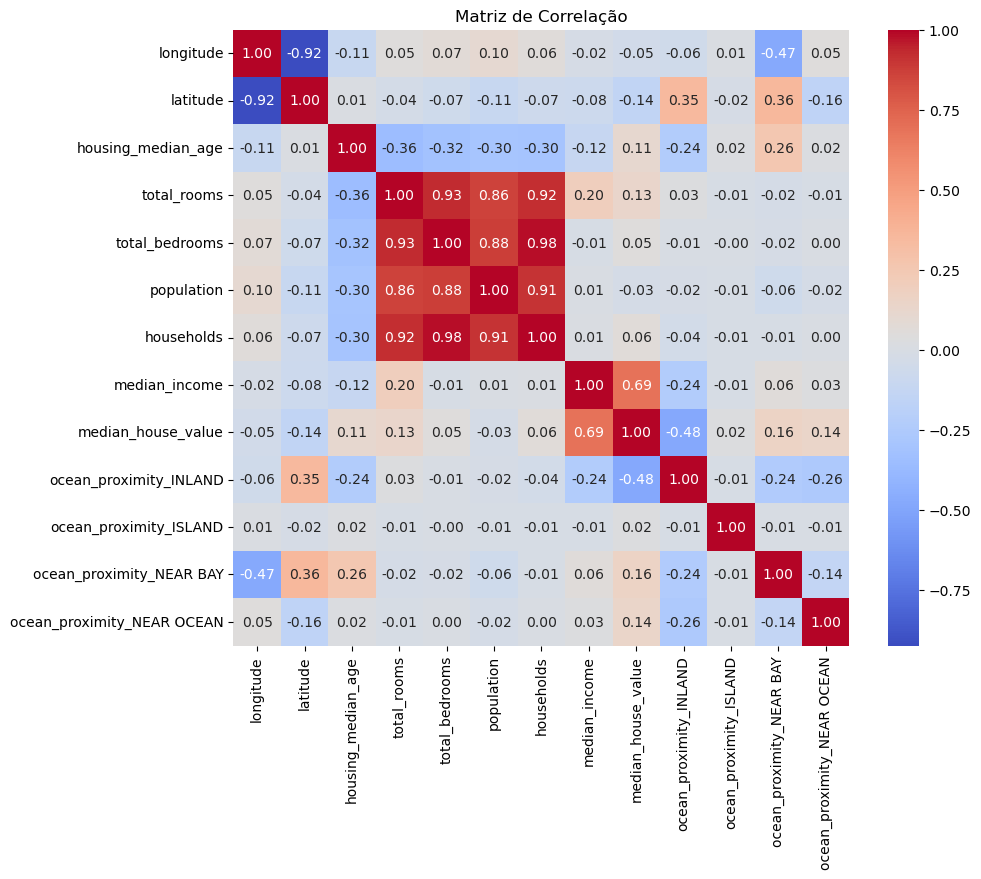

In [35]:
# Calculando a matriz de correlação
correlation_matrix = df.corr()

# Visualizando o heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Matriz de Correlação')
plt.show()

A mediana da renda tem uma correlação de 0.69 com o valor mediano da casa. Ou seja, aqueles com maiores rendas tendem a ter casas mais caras. Assim como, a mediana da idade da habitação tem uma correlação negativa com a quantidade de cômodos e quartos.

### 3. Separe os dados em validação e teste

In [38]:
# Separar as features (X) e o target (y)
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# Dividir os dados em treinamento, validação e teste
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)  # 70% treino
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 15% validação, 15% teste

print(f"Dimensão dos dados de treinamento: {X_train.shape}")
print(f"Dimensão dos dados de validação: {X_val.shape}")
print(f"Dimensão dos dados de teste: {X_test.shape}")

Dimensão dos dados de treinamento: (14303, 12)
Dimensão dos dados de validação: (3065, 12)
Dimensão dos dados de teste: (3065, 12)


### 4. Treine duas árvores, uma com profundidade máxima = 8, outra com profundidade máxima = 2.

In [40]:
# Treinando a árvore com profundidade máxima = 8
tree_depth_8 = DecisionTreeRegressor(max_depth=8, random_state=42)
tree_depth_8.fit(X_train, y_train)

# Treinando a árvore com profundidade máxima = 2
tree_depth_2 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_depth_2.fit(X_train, y_train)

# Exibindo os resultados básicos
print("Árvore com profundidade máxima = 8 treinada!")
print("Árvore com profundidade máxima = 2 treinada!")

Árvore com profundidade máxima = 8 treinada!
Árvore com profundidade máxima = 2 treinada!


### 5. Calcule o MSE de cada uma das árvores do item anterior para a base de treinamento e para a base de testes.

In [44]:


# Fazendo previsões nas bases de treinamento e teste para a árvore com profundidade máxima = 8
y_train_pred_8 = tree_depth_8.predict(X_train)
y_test_pred_8 = tree_depth_8.predict(X_test)

# Calculando o MSE para a árvore com profundidade máxima = 8
mse_train_8 = mean_squared_error(y_train, y_train_pred_8)
mse_test_8 = mean_squared_error(y_test, y_test_pred_8)

print(f"MSE da Árvore (profundidade = 8) - Treinamento: {mse_train_8:.2f}")
print(f"MSE da Árvore (profundidade = 8) - Teste: {mse_test_8:.2f}")

# Fazendo previsões nas bases de treinamento e teste para a árvore com profundidade máxima = 2
y_train_pred_2 = tree_depth_2.predict(X_train)
y_test_pred_2 = tree_depth_2.predict(X_test)

# Calculando o MSE para a árvore com profundidade máxima = 2
mse_train_2 = mean_squared_error(y_train, y_train_pred_2)
mse_test_2 = mean_squared_error(y_test, y_test_pred_2)

print(f"MSE da Árvore (profundidade = 2) - Treinamento: {mse_train_2:.2f}")
print(f"MSE da Árvore (profundidade = 2) - Teste: {mse_test_2:.2f}")


MSE da Árvore (profundidade = 8) - Treinamento: 3155880403.70
MSE da Árvore (profundidade = 8) - Teste: 3881688746.43
MSE da Árvore (profundidade = 2) - Treinamento: 6712935748.76
MSE da Árvore (profundidade = 2) - Teste: 6814196954.22


### 6. Com base nos resultados do item anterior, qual árvore te parece mais adequada?

Se o objetivo for minimizar o overfitting e obter um modelo mais simples e interpretável, a árvore com profundidade = 2 pode ser mais adequada.

### 7. Faça uma visualização gráfica dessa árvore. Vamos discutir importância de variável mais adiante, mas veja a sua árvore, e pense um pouco: qual variável te parece mais "importante" na árvore?

Text(0.5, 1.0, 'Árvore de Decisão - Profundidade Máxima = 2')

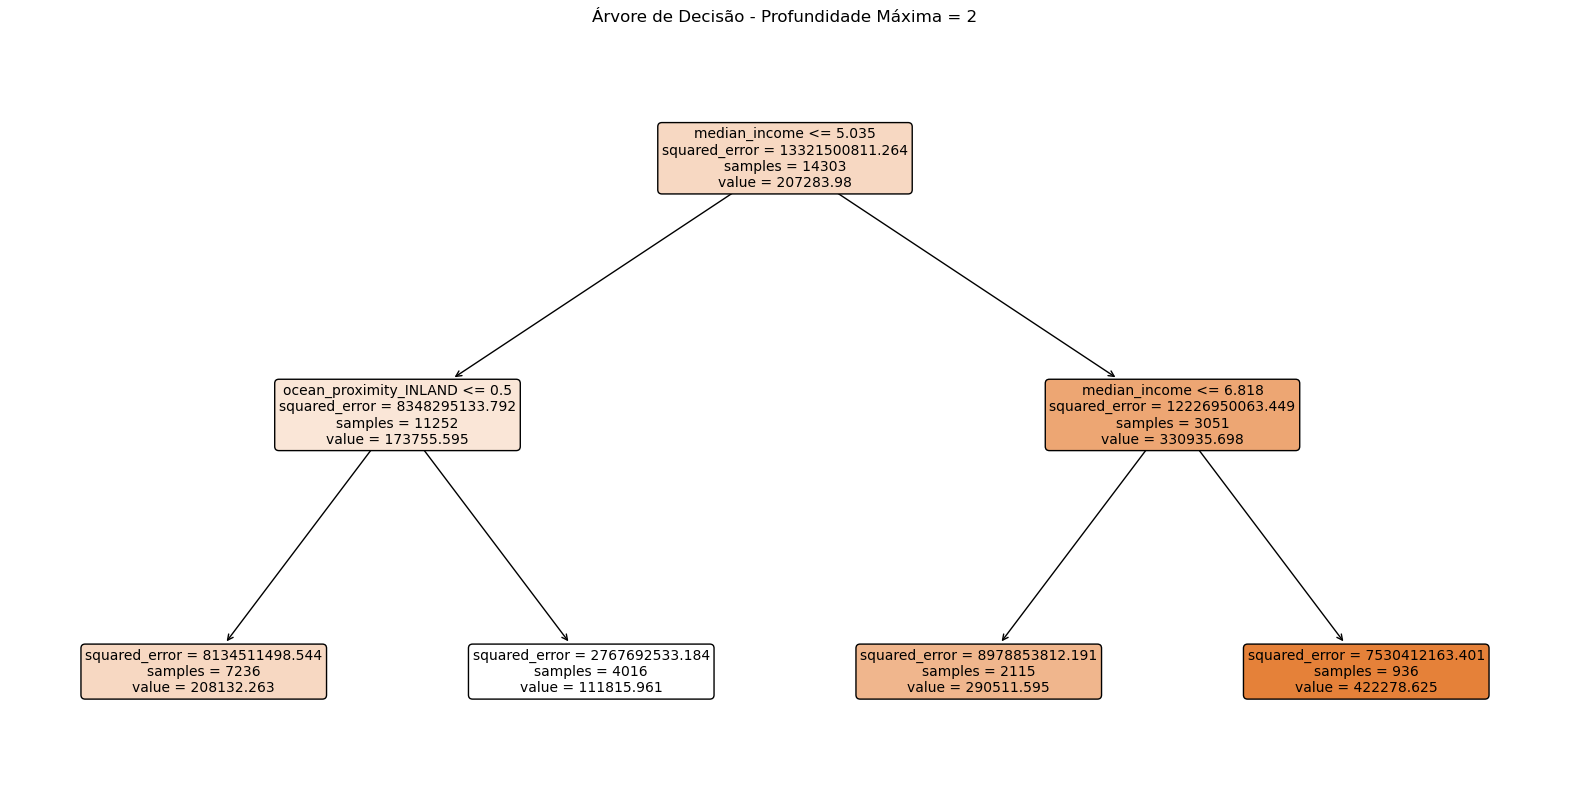

In [49]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Visualizar a árvore com profundidade máxima = 8
plt.figure(figsize=(20, 10))
plot_tree(tree_depth_2, feature_names=X.columns, filled=True, rounded=True, fontsize=10)
plt.title("Árvore de Decisão - Profundidade Máxima = 2")

Ao observar a árvore de decisão com profundidade máxima = 2, é interessante observar como a variável median_income aparece em destaque no nó raiz e também no nó superior. Isso indica que ela exerce uma influência significativa nas divisões iniciais, sugerindo que pode ser uma das variáveis mais preditivas para o alvo, que no caso é o median_house_value.